In [5]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

### What is a Decision Tree?

A **flowchart-like structure** that asks a series of yes/no questions to make predictions.

| | Decision Tree | Random Forest |
|--|---------------|---------------|
| **Number of Trees** | 1 tree | Many trees |
| **Interpretability** | High ✅ | Low ❌ |
| **Overfitting** | Prone to overfitting ❌ | Robust to overfitting ✅ |

| Term | What It Means | Used In |
|------|---------------|---------|
| **1 tree** | The model uses a **single** decision tree | Decision Tree |
| **Many trees** | The model uses **multiple** decision trees (ensemble) | Random Forest |

**Gini Impurity** is a measure of how **impure** or **mixed** a node is in a decision tree. It tells you how often a randomly chosen element would be incorrectly classified if it were randomly labeled according to the distribution of labels in the node.

Gini = 0  →  Perfectly pure ✅

Gini > 0  →  Some mixing ⚠️

Gini = 0.5 → Perfectly mixed ❌ (for 2 classes)

In [7]:
# Small dataset
X, y = make_classification(n_samples=100, n_features=5, random_state=42)

# Decision Tree: Fast, interpretable
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X, y)
print("Decision Tree: Explainable")

# Random Forest: More accurate, slower
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X, y)
print("Random Forest: More accurate")

# Compare accuracy
print(f"DT Accuracy: {dt.score(X, y):.3f}")
print(f"RF Accuracy: {rf.score(X, y):.3f}")

Decision Tree: Explainable
Random Forest: More accurate
DT Accuracy: 1.000
RF Accuracy: 1.000


In [8]:
# fake data
data = pd.DataFrame({
    'age': [25, 32, 45, 18, 60, 35, 22, 28, 50, 30],
    'likes_cheese': ['yes', 'yes', 'no', 'yes', 'no', 'yes', 'yes', 'no', 'yes', 'yes'],
    'loves_pizza': ['yes', 'yes', 'no', 'yes', 'no', 'yes', 'yes', 'yes', 'no', 'yes']  # Target
})

data

,age,likes_cheese,loves_pizza
0,25,yes,yes
1,32,yes,yes
2,45,no,no
3,18,yes,yes
4,60,no,no
5,35,yes,yes
6,22,yes,yes
7,28,no,yes
8,50,yes,no
9,30,yes,yes


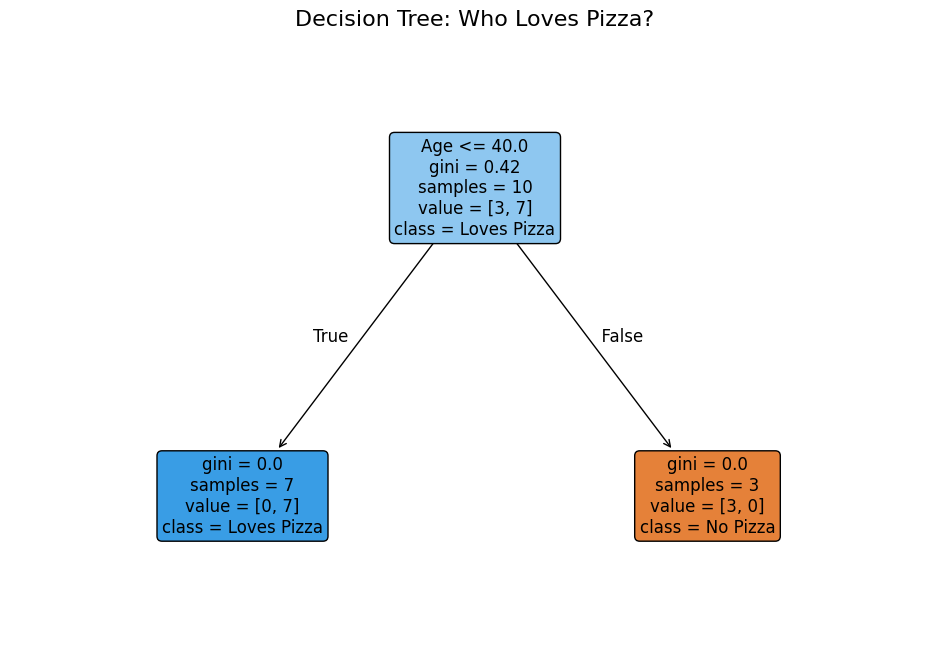

In [9]:
# encode categorical variables
data['likes_cheese_encoded'] = data['likes_cheese'].map({'yes': 1, 'no': 0})
data['loves_pizza_encoded'] = data['loves_pizza'].map({'yes': 1, 'no': 0})


X = data[['age', 'likes_cheese_encoded']]
y = data['loves_pizza_encoded']

dt = DecisionTreeClassifier(max_depth=2, random_state=42)
dt.fit(X, y)


plt.figure(figsize=(12, 8))
plot_tree(
    dt, 
    feature_names=['Age', 'Likes Cheese'],
    class_names=['No Pizza', 'Loves Pizza'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree: Who Loves Pizza?", fontsize=16)
plt.show()

**Gini = 0.42** means the node is **partially mixed** — it's not perfectly pure, but it's not perfectly mixed either.

Node with 10 samples:

 A A A A A A A   B B B     
 (7 samples)    (3 samples)
                           
 70% Class A, 30% Class B  
                           
 Gini = 0.42     

$$
\text{Gini} = 1 - (p_A^2 + p_B^2)
$$

Where:
- $p_A = \frac{7}{10} = 0.7$  (70% Class A)
- $p_B = \frac{3}{10} = 0.3$  (30% Class B)

$$
\text{Gini} = 1 - (0.7^2 + 0.3^2)
$$

$$
\text{Gini} = 1 - (0.49 + 0.09)
$$

$$
\text{Gini} = 1 - 0.58
$$

$$
\boxed{\text{Gini} = 0.42} \quad \checkmark
$$

In [11]:
test_cases = pd.DataFrame([
    {'age': 22, 'likes_cheese': 'yes'},   # Should predict YES (young + cheese)
    {'age': 55, 'likes_cheese': 'no'},    # Should predict NO (old + no cheese)
    {'age': 28, 'likes_cheese': 'no'},    # Should predict YES? (young but no cheese)
    {'age': 48, 'likes_cheese': 'yes'}    # Should predict NO? (old but likes cheese)
])

print("Test Cases:")
print(test_cases)
print()

# encode test cases
test_cases['likes_cheese_encoded'] = test_cases['likes_cheese'].map({'yes': 1, 'no': 0})
X_test = test_cases[['age', 'likes_cheese_encoded']]

predictions = dt.predict(X_test)
probabilities = dt.predict_proba(X_test)


for i, row in test_cases.iterrows():
    pred = 'Loves Pizza' if predictions[i] == 1 else 'No Pizza'
    prob_yes = probabilities[i][1] * 100
    print(f"Age {row['age']}, Likes Cheese: {row['likes_cheese']} → {pred} ({prob_yes:.1f}% confidence)")

Test Cases:
   age likes_cheese
0   22          yes
1   55           no
2   28           no
3   48          yes

Age 22, Likes Cheese: yes → Loves Pizza (100.0% confidence)
Age 55, Likes Cheese: no → No Pizza (0.0% confidence)
Age 28, Likes Cheese: no → Loves Pizza (100.0% confidence)
Age 48, Likes Cheese: yes → No Pizza (0.0% confidence)
